In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

In [2]:
table_desc = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/plots/SupTable_Sample_Stats_wGT_QC.tsv"
metadata_path = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"

metadata_table = pd.read_csv(table_desc, sep="\t")

metadata_20x_filt = metadata_table.loc[(metadata_table.finalQC != "fail")
                              & (metadata_table.cov_chrA >= 20)
                              & (metadata_table.remove_as_relative != True)
                              & (metadata_table.remove_manual != True)
                              & (~metadata_table.ID.str.startswith("SAMEA11633"))
                             ]

count_sub = metadata_20x_filt.loc[~metadata_20x_filt.cov_chrX.isna()][["gSEX", "group", "species_genotyping", "species"]].value_counts().reset_index()
used_species = count_sub.loc[(count_sub.gSEX == "F") | ((count_sub.gSEX == "M") & (count_sub["count"] >= 2))].species_genotyping.unique()
metadata_20x_filt = metadata_20x_filt.loc[metadata_20x_filt.species_genotyping.isin(used_species)]

In [3]:
# Loading in the species
df_l = []
for long_form in used_species:
    df_path = "../results/lifted_window_stats_20x_inds/{}_10kb_pi_windowed_annotated.txt".format(long_form)
    s_df = pd.read_csv(df_path, sep="\t")
    s_df["species"] = long_form
    df_l.append(s_df)
all_pi_df = pd.concat(df_l)

In [4]:
chr_names = ['NC_060925.1', 'NC_060926.1', 'NC_060927.1', 'NC_060928.1',
       'NC_060929.1', 'NC_060930.1', 'NC_060931.1', 'NC_060932.1',
       'NC_060933.1', 'NC_060934.1', 'NC_060935.1', 'NC_060936.1',
       'NC_060937.1', 'NC_060938.1', 'NC_060939.1', 'NC_060940.1',
       'NC_060941.1', 'NC_060942.1', 'NC_060943.1', 'NC_060944.1',
       'NC_060945.1', 'NC_060946.1', 'NC_060947.1']
chr_tag = ["chrX" if i == 22 else "aut" for i in range(len(chr_names))]
all_pi_df["chr_type"] = all_pi_df.chrom.map(dict(zip(chr_names, chr_tag)))
all_pi_df

,chrom,window_100kb,pi_window,mapped_bases,pi_per_mapped_base,genes,max_genes,largest_gene,largest_gene_cov,species,chr_type
0,NC_060925.1,0,220.560738,47016,0.004691,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp,aut
1,NC_060925.1,100000,4.757545,1214,0.003919,['OR4F21'],0,OR4F21,0.00938,Macaca_fascicularis_ssp,aut
2,NC_060925.1,200000,212.822104,58860,0.003616,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp,aut
3,NC_060925.1,300000,269.197770,63277,0.004254,['SAMD11' 'NOC2L' 'PLEKHN1' 'KLHL17'],0,SAMD11,0.17321,Macaca_fascicularis_ssp,aut
4,NC_060925.1,400000,237.559592,81586,0.002912,['AGRN' 'PERM1' 'PLEKHN1' 'HES4' 'ISG15'],0,AGRN,0.34747,Macaca_fascicularis_ssp,aut
...,...,...,...,...,...,...,...,...,...,...,...
28351,NC_060947.1,153800000,12.916500,52722,0.000245,['TMLHE'],0,TMLHE,0.94993,Colobus_angolensis_ssp,chrX
28352,NC_060947.1,153900000,25.446100,57182,0.000445,['SPRY3'],0,SPRY3,0.00867,Colobus_angolensis_ssp,chrX
28353,NC_060947.1,154000000,15.207100,26499,0.000574,NaN,0,NaN,0.00000,Colobus_angolensis_ssp,chrX
28354,NC_060947.1,154100000,46.386000,65465,0.000709,['VAMP7'],0,VAMP7,0.52682,Colobus_angolensis_ssp,chrX


In [6]:
# Test set
species_used = [used_species[i] for i in range(0, len(used_species), 20)]

In [7]:
x_m = np.ones((len(species_used), len(species_used)))
aut_m = np.ones((len(species_used), len(species_used)))
for i in range(len(species_used)):
    for j in range(i):
        s1 = species_used[i]
        s2 = species_used[j]
        merged_df = pd.merge(all_pi_df.loc[(all_pi_df.species == s1) & (all_pi_df.mapped_bases >= 50000)],
                all_pi_df.loc[(all_pi_df.species == s2) & (all_pi_df.mapped_bases >= 50000)],
                on=["chrom", "window_100kb"])
        merged_df_x = merged_df.loc[merged_df.chr_type_x == "chrX"]
        cor_x = merged_df_x[["pi_per_mapped_base_x", "pi_per_mapped_base_y"]].corr(method="spearman").iloc[0, 1]
        x_m[i, j] = cor_x
        x_m[j, i] = cor_x
        merged_df_aut = merged_df.loc[merged_df.chr_type_x == "aut"]
        cor_aut = merged_df_aut[["pi_per_mapped_base_x", "pi_per_mapped_base_y"]].corr(method="spearman").iloc[0, 1]
        aut_m[i, j] = cor_aut
        aut_m[j, i] = cor_aut

In [8]:
(aut_m-x_m).sum()/(len(species_used)*(len(species_used)-1)/2)

0.22482600600261277

In [9]:
(aut_m.sum()-len(species_used))/(len(species_used)*(len(species_used)-1)/2)

0.6254549568805342

In [10]:
(x_m.sum()-len(species_used))/(len(species_used)*(len(species_used)-1)/2)

0.4006289508779214

In [11]:
aut_m.mean()-x_m.mean()

0.10117170270117576

In [12]:
comp_list = []
for i in range(len(aut_m)):
    for j in range(i):
        comp_list.append(aut_m[i, j]-x_m[i, j])

<Axes: ylabel='Count'>

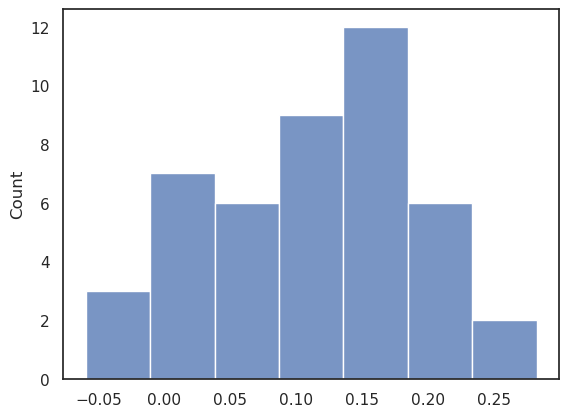

In [13]:
sns.histplot(comp_list)

<Axes: >

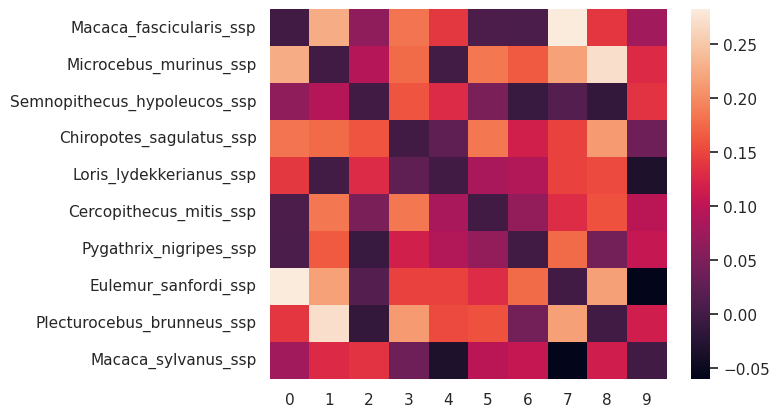

In [14]:
sns.heatmap(aut_m-x_m, yticklabels=species_used)

Full run

In [15]:
species_used = [used_species[i] for i in range(0, len(used_species), 1)]

In [16]:
x_m = np.ones((len(species_used), len(species_used)))
aut_m = np.ones((len(species_used), len(species_used)))
for i in range(len(species_used)):
    print(i)
    for j in range(i):
        s1 = species_used[i]
        s2 = species_used[j]
        merged_df = pd.merge(all_pi_df.loc[(all_pi_df.species == s1) & (all_pi_df.mapped_bases >= 50000)],
                all_pi_df.loc[(all_pi_df.species == s2) & (all_pi_df.mapped_bases >= 50000)],
                on=["chrom", "window_100kb"])
        merged_df_x = merged_df.loc[merged_df.chr_type_x == "chrX"]
        cor_x = merged_df_x[["pi_per_mapped_base_x", "pi_per_mapped_base_y"]].corr(method="spearman").iloc[0, 1]
        x_m[i, j] = cor_x
        x_m[j, i] = cor_x
        merged_df_aut = merged_df.loc[merged_df.chr_type_x == "aut"]
        cor_aut = merged_df_aut[["pi_per_mapped_base_x", "pi_per_mapped_base_y"]].corr(method="spearman").iloc[0, 1]
        aut_m[i, j] = cor_aut
        aut_m[j, i] = cor_aut

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192


In [23]:
# Saving the dataframes
#pd.DataFrame(aut_m, columns=species_used).to_csv("../results/aut_correlations.txt", sep="\t", index=False)
#pd.DataFrame(x_m, columns=species_used).to_csv("../results/x_correlations.txt", sep="\t", index=False)

In [3]:
# Loading the dataframes
aut_df = pd.read_csv("../results/aut_correlations.txt", sep="\t")
x_df = pd.read_csv("../results/x_correlations.txt", sep="\t")

In [4]:
from skbio import DistanceMatrix
from skbio.tree import nj
from skbio.tree import upgma
from skbio.tree import bme
from skbio import TreeNode

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import gridspec

from Bio import Phylo
import numpy as np

primate_tree = TreeNode.read("../data/Craig_Kumar_Hedges_final_timetree.nwk")
primate_tree

<TreeNode, name: unnamed, internal node count: 453, tips count: 455>

In [5]:
species_used = [used_species[i] for i in range(0, len(used_species), 1)]
species_list = ["{} {}".format(x.split("_")[0], x.split("_")[1]) for x in species_used]

In [6]:
species_list

['Macaca fascicularis',
 'Pan troglodytes',
 'Papio anubis',
 'Macaca mulatta',
 'Macaca fuscata',
 'Papio cynocephalus',
 'Gorilla gorilla',
 'Papio hamadryas',
 'Macaca nemestrina',
 'Papio kindae',
 'Gorilla beringei',
 'Pan paniscus',
 'Sapajus apella',
 'Pongo abelii',
 'Pongo pygmaeus',
 'Alouatta seniculus',
 'Cacajao calvus',
 'Macaca silenus',
 'Macaca radiata',
 'Aotus nancymaae',
 'Microcebus murinus',
 'Aotus azarai',
 'Saimiri cassiquiarensis',
 'Papio papio',
 'Hoolock hoolock',
 'Saimiri ustus',
 'Trachypithecus francoisi',
 'Macaca tonkeana',
 'Nycticebus bengalensis',
 'Macaca arctoides',
 'Daubentonia madagascariensis',
 'Ateles chamek',
 'Trachypithecus poliocephalus',
 'Theropithecus gelada',
 'Cercocebus atys',
 'Papio ursinus',
 'Cheracebus lugens',
 'Pygathrix nemaeus',
 'Rhinopithecus roxellana',
 'Macaca maura',
 'Semnopithecus hypoleucos',
 'Macaca hecki',
 'Pygathrix cinerea',
 'Cercopithecus mona',
 'Saimiri macrodon',
 'Lemur catta',
 'Aotus griseimembra',


In [7]:
trimmed_list = []
for node in primate_tree.tips():
    if node.name in species_list:
        trimmed_list.append(node.name)
primate_tree.lca(['Pongo abelii', 'Gorilla gorilla']).height()

(17.58, <TreeNode, name: Homo sapiens, internal node count: 0, tips count: 0>)

In [8]:
len(trimmed_list), len(species_list)

(190, 193)

In [9]:
# Traverse and get the pairing and correlation.
s1_l, s2_l, aut_cor_l, x_cor_l, height_l = [], [], [], [], []
for i in range(len(species_used)):
    for j in range(i):
        s1 = species_used[i]
        s2 = species_used[j]
        s1_l.append(s1)
        s2_l.append(s2)
        aut_cor_l.append(aut_df.iloc[i, j])
        x_cor_l.append(x_df.iloc[i, j])
        try:
            height_l.append(primate_tree.lca([species_list[i], species_list[j]]).height()[0])
        except:
            height_l.append(np.NaN)
cor_df = pd.DataFrame({"s1": s1_l, "s2": s2_l, "aut_correlation": aut_cor_l, "x_correlation": x_cor_l,
                     "lca": height_l})
cor_df["x_aut_difference"] = cor_df.aut_correlation-cor_df.x_correlation
cor_df_x = pd.DataFrame({"s1": s1_l, "s2": s2_l, "correlation": x_cor_l,
                     "lca": height_l})
cor_df_x["chr_type"] = "chrX"
cor_df_aut = pd.DataFrame({"s1": s1_l, "s2": s2_l, "correlation": aut_cor_l,
                     "lca": height_l})
cor_df_aut["chr_type"] = "aut"

In [10]:
cor_df.loc[cor_df.s2 == "Macaca_fascicularis_ssp"]

,s1,s2,aut_correlation,x_correlation,lca,x_aut_difference
0,Pan_troglodytes_ssp,Macaca_fascicularis_ssp,0.501822,0.515063,29.43,-0.013241
1,Papio_anubis_ssp,Macaca_fascicularis_ssp,0.657775,0.646425,10.54,0.011350
3,Macaca_mulatta_ssp,Macaca_fascicularis_ssp,0.870107,0.841370,2.88,0.028738
6,Macaca_fuscata_ssp,Macaca_fascicularis_ssp,0.535022,0.660627,2.88,-0.125604
10,Papio_cynocephalus_ssp,Macaca_fascicularis_ssp,0.746359,0.790904,10.54,-0.044544
...,...,...,...,...,...,...
17578,Cercocebus_chrysogaster_ssp,Macaca_fascicularis_ssp,0.343655,0.323298,10.54,0.020356
17766,Cercopithecus_denti_ssp,Macaca_fascicularis_ssp,0.555618,0.536219,13.08,0.019399
17955,Cercopithecus_hamlyni_ssp,Macaca_fascicularis_ssp,0.624885,0.657021,13.08,-0.032136
18145,Cercopithecus_roloway_ssp,Macaca_fascicularis_ssp,0.552491,0.608870,13.08,-0.056379


<Axes: xlabel='lca', ylabel='aut_correlation'>

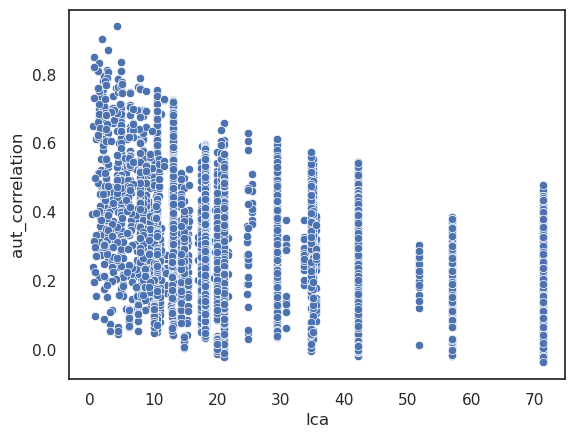

In [11]:
sns.scatterplot(cor_df, x="lca", y="aut_correlation")

<Axes: xlabel='lca', ylabel='x_correlation'>

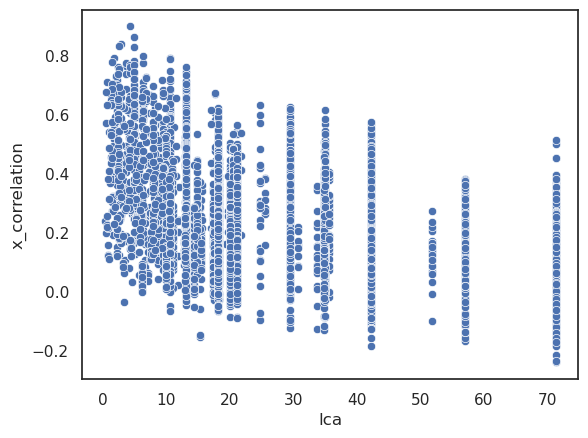

In [12]:
sns.scatterplot(cor_df, x="lca", y="x_correlation")

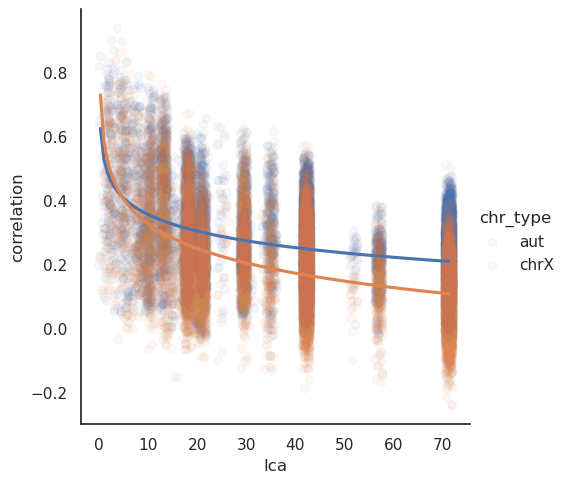

In [13]:
long_corr = pd.concat([cor_df_aut, cor_df_x])
sns.lmplot(long_corr, x="lca", y="correlation", hue="chr_type", 
           logx=True, scatter_kws={'alpha':0.05}, x_jitter=.75)

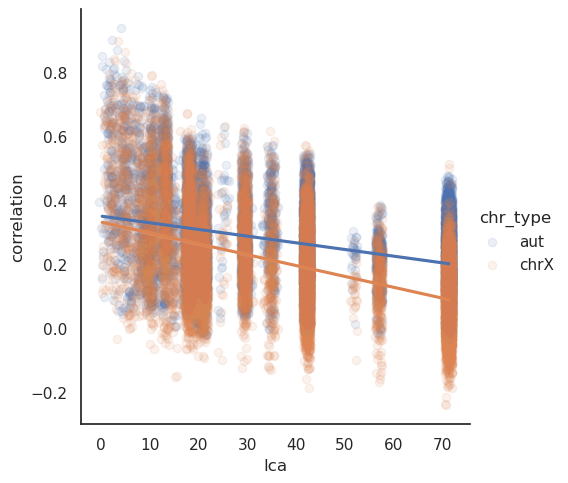

In [14]:
sns.lmplot(long_corr, x="lca", y="correlation", hue="chr_type", scatter_kws={'alpha':0.1}, x_jitter=.75)

<Axes: xlabel='lca', ylabel='x_aut_difference'>

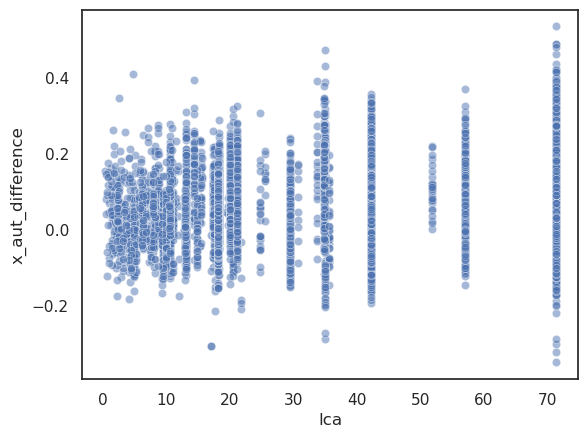

In [15]:
sns.scatterplot(cor_df, x="lca", y="x_aut_difference", alpha=0.5)

<Axes: xlabel='lca', ylabel='aut_correlation'>

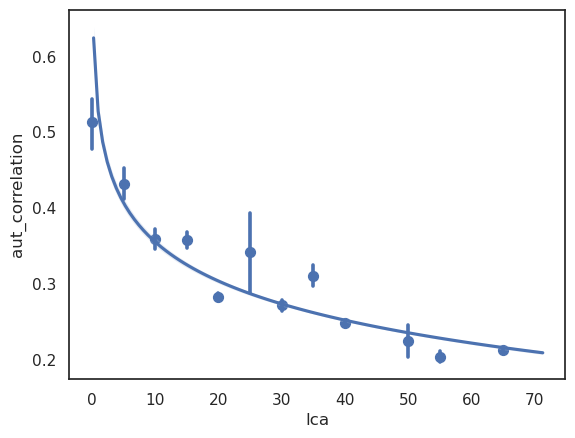

In [16]:
sns.regplot(data=cor_df, x="lca", y="aut_correlation", logx=True, x_bins=np.arange(0, 70, 5))

<Axes: xlabel='lca', ylabel='x_aut_difference'>

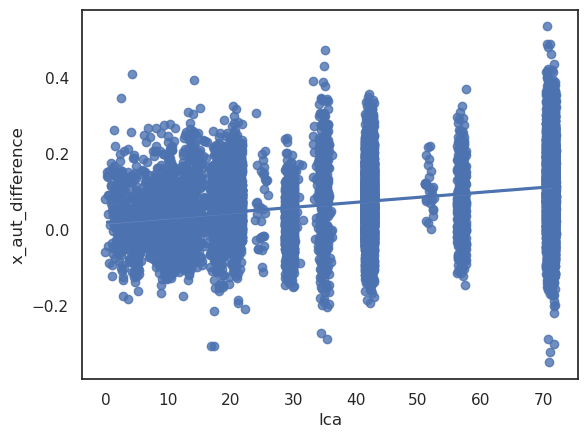

In [17]:
sns.regplot(cor_df, x="lca", y="x_aut_difference", x_jitter=0.75)

Binning and tests.

In [18]:
cor_df["bins"] = pd.cut(cor_df.lca, bins=np.arange(0, 81, 20))
cor_df.groupby(["bins"])[["aut_correlation", "x_correlation"]].mean()

/tmp/34191133/ipykernel_2407231/3012469808.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cor_df.groupby(["bins"])[["aut_correlation", "x_correlation"]].mean()


,aut_correlation,x_correlation
bins,,
"(0, 20]",0.339032,0.296414
"(20, 40]",0.274947,0.223969
"(40, 60]",0.244827,0.176341
"(60, 80]",0.212600,0.096286


In [19]:
cor_df["bins"] = pd.cut(cor_df.lca, bins=np.arange(0, 81, 5))
cor_df.groupby(["bins"])[["aut_correlation", "x_correlation"]].mean()

/tmp/34191133/ipykernel_2407231/3283496453.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cor_df.groupby(["bins"])[["aut_correlation", "x_correlation"]].mean()


,aut_correlation,x_correlation
bins,,
"(0, 5]",0.478315,0.457865
"(5, 10]",0.340605,0.314146
"(10, 15]",0.399414,0.356517
"(15, 20]",0.286600,0.236291
"(20, 25]",0.266554,0.197032
"(25, 30]",0.273502,0.254460
"(30, 35]",0.305167,0.173267
"(35, 40]",0.307201,0.245125
"(40, 45]",0.247587,0.178865


In [20]:
cor_df

,s1,s2,aut_correlation,x_correlation,lca,x_aut_difference,bins
0,Pan_troglodytes_ssp,Macaca_fascicularis_ssp,0.501822,0.515063,29.43,-0.013241,"(25, 30]"
1,Papio_anubis_ssp,Macaca_fascicularis_ssp,0.657775,0.646425,10.54,0.011350,"(10, 15]"
2,Papio_anubis_ssp,Pan_troglodytes_ssp,0.411562,0.394056,29.43,0.017506,"(25, 30]"
3,Macaca_mulatta_ssp,Macaca_fascicularis_ssp,0.870107,0.841370,2.88,0.028738,"(0, 5]"
4,Macaca_mulatta_ssp,Pan_troglodytes_ssp,0.477969,0.517732,29.43,-0.039763,"(25, 30]"
...,...,...,...,...,...,...,...
18523,Colobus_angolensis_ssp,Allochrocebus_preussi_ssp,0.149563,0.064580,18.07,0.084983,"(15, 20]"
18524,Colobus_angolensis_ssp,Cercocebus_chrysogaster_ssp,0.141188,0.102340,18.07,0.038848,"(15, 20]"
18525,Colobus_angolensis_ssp,Cercopithecus_denti_ssp,0.236825,0.187955,18.07,0.048869,"(15, 20]"
18526,Colobus_angolensis_ssp,Cercopithecus_hamlyni_ssp,0.263722,0.204593,18.07,0.059129,"(15, 20]"


In [21]:
# Determining if the correlations are different across groups.
cor_df["s1_group"] = cor_df.s1.map(dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group)))
cor_df["s2_group"] = cor_df.s2.map(dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group)))

In [22]:
same_group = cor_df.loc[(cor_df.s1_group == cor_df.s2_group) & (cor_df.lca <= 5)]
same_group.groupby(["s1_group"])[["aut_correlation", "x_correlation"]].mean()

,aut_correlation,x_correlation
s1_group,,
APE,0.398132,0.409531
OWM,0.497896,0.498174
PLA,0.436680,0.382652
STR,0.549566,0.406198


In [23]:
same_group = cor_df.loc[(cor_df.s1_group == cor_df.s2_group) & (cor_df.lca <= 10)]
same_group.groupby(["s1_group"])[["aut_correlation", "x_correlation"]].mean()

,aut_correlation,x_correlation
s1_group,,
APE,0.293375,0.314275
OWM,0.395201,0.385331
PLA,0.390983,0.322745
STR,0.564341,0.445788


In [24]:
same_group = cor_df.loc[(cor_df.s1_group == cor_df.s2_group) & (cor_df.lca >= 10)]
same_group.groupby(["s1_group"])[["aut_correlation", "x_correlation"]].mean()

,aut_correlation,x_correlation
s1_group,,
APE,0.303500,0.334947
OWM,0.353916,0.320588
PLA,0.254583,0.176425
STR,0.268884,0.191851


In [25]:
same_group

,s1,s2,aut_correlation,x_correlation,lca,x_aut_difference,bins,s1_group,s2_group
1,Papio_anubis_ssp,Macaca_fascicularis_ssp,0.657775,0.646425,10.54,0.011350,"(10, 15]",OWM,OWM
5,Macaca_mulatta_ssp,Papio_anubis_ssp,0.653144,0.617682,10.54,0.035462,"(10, 15]",OWM,OWM
8,Macaca_fuscata_ssp,Papio_anubis_ssp,0.425766,0.484028,10.54,-0.058262,"(10, 15]",OWM,OWM
10,Papio_cynocephalus_ssp,Macaca_fascicularis_ssp,0.746359,0.790904,10.54,-0.044544,"(10, 15]",OWM,OWM
13,Papio_cynocephalus_ssp,Macaca_mulatta_ssp,0.739334,0.748014,10.54,-0.008680,"(10, 15]",OWM,OWM
...,...,...,...,...,...,...,...,...,...
18523,Colobus_angolensis_ssp,Allochrocebus_preussi_ssp,0.149563,0.064580,18.07,0.084983,"(15, 20]",OWM,OWM
18524,Colobus_angolensis_ssp,Cercocebus_chrysogaster_ssp,0.141188,0.102340,18.07,0.038848,"(15, 20]",OWM,OWM
18525,Colobus_angolensis_ssp,Cercopithecus_denti_ssp,0.236825,0.187955,18.07,0.048869,"(15, 20]",OWM,OWM
18526,Colobus_angolensis_ssp,Cercopithecus_hamlyni_ssp,0.263722,0.204593,18.07,0.059129,"(15, 20]",OWM,OWM


In [26]:
diff_group = cor_df.loc[(cor_df.s1_group != cor_df.s2_group) & (cor_df.s2_group != "STR")]
diff_group.groupby(["s1_group"])[["aut_correlation", "x_correlation"]].mean()

,aut_correlation,x_correlation
s1_group,,
APE,0.237985,0.205248
OWM,0.248540,0.186927
PLA,0.258717,0.190676
STR,0.230603,0.104748


In [27]:
diff_group.lca.unique()

array([29.43, 42.19, 71.25,   nan])

In [28]:
diff_group = cor_df.loc[(cor_df.s1_group != cor_df.s2_group) & (cor_df.s2_group == "STR")]
diff_group.groupby(["s1_group"])[["aut_correlation", "x_correlation"]].mean()

,aut_correlation,x_correlation
s1_group,,
APE,0.179540,0.105161
OWM,0.187159,0.087372
PLA,0.181683,0.078346


In [29]:
diff_group.lca.unique()

array([71.25,   nan])

In [30]:
str_only = cor_df.loc[(cor_df.s2_group == "STR") & (cor_df.s1_group == "STR")]
str_only.lca.unique()

array([56.97, 51.81, 34.73, 35.02,   nan, 20.53,  7.46,  4.29, 33.74,
       24.68, 35.53, 11.13,  4.66, 24.79,  4.21,  1.96,  1.29, 15.6 ,
        6.01,  2.47, 25.54, 12.  , 30.77, 16.95, 10.89, 14.33, 10.82,
        1.16,  9.72,  7.64,  1.26, 19.72, 11.55,  1.59, 21.74,  7.37,
        8.72,  5.43, 15.3 ,  0.85, 19.42])

In [31]:
str_only["bins"] = pd.cut(str_only.lca, bins=np.arange(0, 61, 10))
str_only.groupby(["bins"])[["aut_correlation", "x_correlation"]].mean()

/tmp/34191133/ipykernel_2407231/1962658083.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  str_only["bins"] = pd.cut(str_only.lca, bins=np.arange(0, 61, 10))
/tmp/34191133/ipykernel_2407231/1962658083.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  str_only.groupby(["bins"])[["aut_correlation", "x_correlation"]].mean()


,aut_correlation,x_correlation
bins,,
"(0, 10]",0.564341,0.445788
"(10, 20]",0.370773,0.315448
"(20, 30]",0.397746,0.325756
"(30, 40]",0.306242,0.211243
"(40, 50]",NaN,NaN
"(50, 60]",0.205057,0.139970


In [33]:
# Credit to Vasili Pankratov for consolidating this data
mating_vas = pd.read_excel("../data/PrimatePhenotypes_december.xlsx", sheet_name=8)
mating_vas["ssp_name"] = [x+"_ssp" for x in mating_vas.binomial_name]
mating_vas

,binomial_name,Monogamous,Polygynous,Polygynandrous,Polyandrous,lowSC,highSC,consensus,comment,Juliana_Christina,genus_comment,ssp_name
0,Allenopithecus_nigroviridis,0,0,1,0,0,1,Polygynandrous,NaN,NaN,NaN,Allenopithecus_nigroviridis_ssp
1,Allocebus_trichotis,2,1,0,0,3,0,Monogamous,NaN,NaN,NaN,Allocebus_trichotis_ssp
2,Allochrocebus_lhoesti,0,3,0,0,3,0,Polygynous,NaN,NaN,NaN,Allochrocebus_lhoesti_ssp
3,Allochrocebus_preussi,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN,Allochrocebus_preussi_ssp
4,Allochrocebus_solatus,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN,Allochrocebus_solatus_ssp
...,...,...,...,...,...,...,...,...,...,...,...,...
311,Trachypithecus_phayrei,0,2,1,0,2,1,NaN,conflicting,NaN,NaN,Trachypithecus_phayrei_ssp
312,Trachypithecus_pileatus,0,2,0,0,2,0,Polygynous,NaN,NaN,NaN,Trachypithecus_pileatus_ssp
313,Trachypithecus_selangorensis,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN,Trachypithecus_selangorensis_ssp
314,Varecia_rubra,0,1,1,0,1,1,NaN,conflicting,NaN,NaN,Varecia_rubra_ssp


In [35]:
cor_df["s1_strat"] = cor_df.s1.map(dict(zip(mating_vas.ssp_name, mating_vas.consensus)))
cor_df["s2_strat"] = cor_df.s2.map(dict(zip(mating_vas.ssp_name, mating_vas.consensus)))

In [47]:
same_strat = cor_df.loc[(cor_df.s1_strat == cor_df.s2_strat)]
same_strat.groupby(["s1_strat"])[["aut_correlation", "x_correlation"]].mean()
same_strat["bins"] = pd.cut(same_strat.lca, bins=np.arange(0, 81, 20))
same_strat.groupby(["s1_strat", "bins"])[["aut_correlation", "x_correlation"]].mean()

/tmp/34191133/ipykernel_2407231/3772494824.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  same_strat["bins"] = pd.cut(same_strat.lca, bins=np.arange(0, 81, 20))
/tmp/34191133/ipykernel_2407231/3772494824.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  same_strat.groupby(["s1_strat", "bins"])[["aut_correlation", "x_correlation"]].mean()


aut_correlation  x_correlation
s1_strat       bins                                    
Monogamous     (0, 20]          0.318522       0.266555
               (20, 40]         0.255383       0.186106
               (40, 60]         0.198510       0.164654
               (60, 80]         0.203093       0.089780
Polygynandrous (0, 20]          0.403499       0.382732
               (20, 40]         0.303724       0.278068
               (40, 60]         0.253754       0.183853
               (60, 80]         0.210051       0.095206
Polygynous     (0, 20]          0.356201       0.319745
               (20, 40]         0.352038       0.306694
               (40, 60]         0.252162       0.205211
               (60, 80]         0.220849       0.106880

In [65]:
diff_strat = cor_df.loc[(cor_df.s1_strat != cor_df.s2_strat)]
diff_strat.groupby(["s1_strat"])[["aut_correlation", "x_correlation"]].mean()
diff_strat["bins"] = pd.cut(diff_strat.lca, bins=np.arange(0, 46, 5))
diff_strat.groupby(["s1_strat", "bins"])[["aut_correlation", "x_correlation"]].mean()

/tmp/34191133/ipykernel_2407231/2341363454.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diff_strat["bins"] = pd.cut(diff_strat.lca, bins=np.arange(0, 46, 5))
/tmp/34191133/ipykernel_2407231/2341363454.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diff_strat.groupby(["s1_strat", "bins"])[["aut_correlation", "x_correlation"]].mean()


aut_correlation  x_correlation
s1_strat       bins                                    
Monogamous     (0, 5]           0.392881       0.271087
               (5, 10]          0.316610       0.261882
               (10, 15]         0.275077       0.187501
               (15, 20]         0.232683       0.161184
               (20, 25]         0.292651       0.216297
               (25, 30]         0.247587       0.215809
               (30, 35]         0.398167       0.202940
               (35, 40]         0.286120       0.238442
               (40, 45]         0.262195       0.190016
Polyandrous    (0, 5]                NaN            NaN
               (5, 10]               NaN            NaN
               (10, 15]              NaN            NaN
               (15, 20]              NaN            NaN
               (20, 25]              NaN            NaN
               (25, 30]              NaN            NaN
               (30, 35]              NaN            NaN
               (35, 40]         0.474284       0.455705
               (40, 45]              NaN            NaN
Polygynandrous (0, 5]           0.525420       0.499067
               (5, 10]          0.315323       0.291547
               (10, 15]         0.338871       0.302841
               (15, 20]         0.254151       0.188247
               (20, 25]         0.249827       0.193620
               (25, 30]         0.279964       0.246257
               (30, 35]         0.171313       0.073322
               (35, 40]         0.255727       0.156307
               (40, 45]         0.228051       0.153436
Polygynous     (0, 5]           0.388347       0.387005
               (5, 10]          0.343538       0.332549
               (10, 15]         0.450170       0.407265
               (15, 20]         0.303731       0.259687
               (20, 25]         0.245480       0.186744
               (25, 30]         0.261077       0.260191
               (30, 35]         0.288256       0.224819
               (35, 40]         0.306595       0.258196
               (40, 45]         0.249139       0.177496

In [50]:
same_strat

,s1,s2,aut_correlation,x_correlation,lca,x_aut_difference,bins,s1_group,s2_group,s1_strat,s2_strat
0,Pan_troglodytes_ssp,Macaca_fascicularis_ssp,0.501822,0.515063,29.43,-0.013241,"(20, 40]",APE,OWM,Polygynandrous,Polygynandrous
1,Papio_anubis_ssp,Macaca_fascicularis_ssp,0.657775,0.646425,10.54,0.011350,"(0, 20]",OWM,OWM,Polygynandrous,Polygynandrous
2,Papio_anubis_ssp,Pan_troglodytes_ssp,0.411562,0.394056,29.43,0.017506,"(20, 40]",OWM,APE,Polygynandrous,Polygynandrous
3,Macaca_mulatta_ssp,Macaca_fascicularis_ssp,0.870107,0.841370,2.88,0.028738,"(0, 20]",OWM,OWM,Polygynandrous,Polygynandrous
4,Macaca_mulatta_ssp,Pan_troglodytes_ssp,0.477969,0.517732,29.43,-0.039763,"(20, 40]",OWM,APE,Polygynandrous,Polygynandrous
...,...,...,...,...,...,...,...,...,...,...,...
18520,Colobus_angolensis_ssp,Presbytis_melalophos_ssp,0.208995,0.129642,12.87,0.079353,"(0, 20]",OWM,OWM,Polygynous,Polygynous
18523,Colobus_angolensis_ssp,Allochrocebus_preussi_ssp,0.149563,0.064580,18.07,0.084983,"(0, 20]",OWM,OWM,Polygynous,Polygynous
18525,Colobus_angolensis_ssp,Cercopithecus_denti_ssp,0.236825,0.187955,18.07,0.048869,"(0, 20]",OWM,OWM,Polygynous,Polygynous
18526,Colobus_angolensis_ssp,Cercopithecus_hamlyni_ssp,0.263722,0.204593,18.07,0.059129,"(0, 20]",OWM,OWM,Polygynous,Polygynous


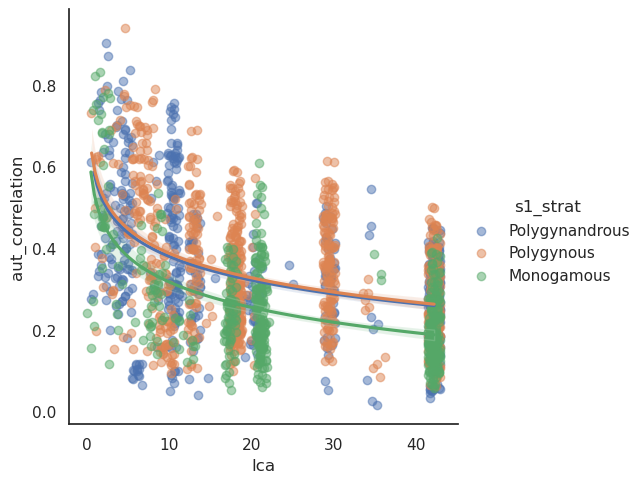

In [57]:
sns.lmplot(same_strat.loc[same_strat.lca <= 50], x="lca", y="aut_correlation", hue="s1_strat", 
           logx=True, scatter_kws={'alpha':0.5}, x_jitter=.75)

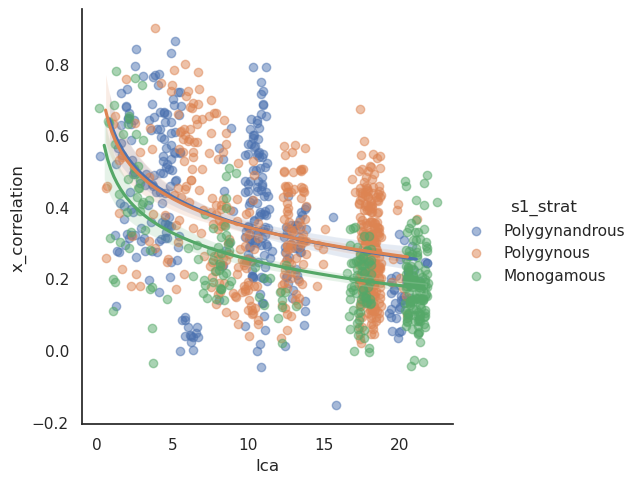

In [67]:
sns.lmplot(same_strat.loc[same_strat.lca <= 24], x="lca", y="x_correlation", hue="s1_strat", 
           logx=True, scatter_kws={'alpha':0.5}, x_jitter=.75)

Seems as if similar mating strategies does have an effect in causing similar diversity landscapes, but it's hard to judge like this. Should probably implement in a regression-style analysis or more explicit iterate through the lca as a contrast.